In [4]:
import pandas as pd
import numpy as np
import uuid
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('ActionLog (1).csv')

In [6]:
print("\nMissing values:")
print(df.isnull().sum())
print(df.shape)


Missing values:
CompanyName        0
Industry        9329
LogType            0
Log Date           0
message           37
DealAmount     24158
dtype: int64
(31874, 6)


In [7]:
unique_counts = df.nunique()
print("Unique value counts for each column:")
print(unique_counts)

num_companies = df['CompanyName'].nunique()
print("Number of unique company names:", num_companies)


Unique value counts for each column:
CompanyName     7217
Industry          50
LogType            5
Log Date       31855
message        17660
DealAmount       323
dtype: int64
Number of unique company names: 7217


In [8]:
df['CompanyName_basic'] = df['CompanyName'].str.strip().str.lower()
df['CompanyID'] = pd.factorize(df['CompanyName_basic'])[0] + 1
df['Industry'] = df['Industry'].fillna("Unknown").str.lower()
df['message'] = df['message'].fillna("Unknown")
df['Log Date'] = pd.to_datetime(df['Log Date'])

In [9]:
from collections import Counter
import re

followup_messages = df[df['LogType'].str.strip().str.lower() == 'follow-up']['message'].astype(str)

def get_tokens(text):
    text = text.lower()
    text = re.sub(r'[^\w\s\u4e00-\u9fff]', ' ', text)
    return text.split()

all_words = []
for msg in followup_messages:
    all_words.extend(get_tokens(msg))

word_freq = Counter(all_words)

df_word_freq = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

print("Follow-up中既Top50詞")
print(df_word_freq.head(60))

Follow-up中既Top50詞
             Word  Frequency
10           send       6385
56             to       5029
21            job       4634
1             the       3303
113         email       2553
32          offer       2358
17             no       2151
135       package       1928
243          call       1907
30           sent       1896
62           need       1844
63            ask       1686
75           will       1647
100           for       1592
5               1       1505
19            and       1479
221            in       1468
130           pkg       1439
61          chase       1331
35             ad       1278
83             up       1167
6            post       1084
4              of       1067
98           jobs       1058
13            not       1017
82         follow       1012
93        posting        918
46             on        897
117       contact        884
2151          cny        829
24             if        793
26             is        780
77          later        

In [10]:
#將ID23 有錯既logtype轉返followup
fix_id23 = pd.to_datetime([
    '2023-02-13 14:24:53',
    '2023-02-22 09:45:37',
    '2023-03-02 10:01:40',
    '2023-05-04 16:07:08'
])
mask_id23 = (df['CompanyID'] == 23) & (df['Log Date'].isin(fix_id23))
df.loc[mask_id23, 'LogType'] = 'Follow-up'

In [11]:
fix_id = {
    (37, '2023-02-09 17:12:54'): 'Follow-up',
    (1681, '2024-03-07 15:38:03'): 'Follow-up',
    (229, '2023-08-04 11:26:04'): 'Follow-up',
    (1471, '2023-06-05 15:12:50'): 'Proposed',
    (1745, '2023-07-11 16:56:14'): 'Proposed',
    (3795, '2024-04-29 14:38:13'): 'Proposed'
}
for (comp_id, log_time), new_type in fix_id.items():
    df.loc[(df['CompanyID'] == comp_id) & (df['Log Date'] == pd.to_datetime(log_time)), ['LogType', 'Is_Rejected']] = [new_type, 0]

In [12]:
id427_prop_date = pd.to_datetime('2024-01-25 10:42:46')
df.loc[(df['CompanyID'] == 427) & (df['Log Date'] == id427_prop_date), 'LogType'] = 'Proposed'

In [13]:
df['Is_Signed'] = (df['LogType'] == 'Signed').astype(int)
df['Is_Rejected'] = (df['LogType'] == 'Rejected').astype(int)

In [14]:
#將字分成salesattempt同postsales
def classify_log_strict(row):
    log_type = str(row['LogType']).strip().lower()
    msg = str(row['message']).lower()

    sales_keywords = ['package', 'pkg', 'pac', 'info', 'offer', 'propose', 'quote', 'quotation', 'recruitment', 'answer', 'need', 'quo', 'needed','order','revise']

    post_sales_keywords = ['amend', 'invoice', 'payment', 'post']

    if log_type == 'proposed':
        return "Sales Attempt"

    if log_type == 'follow-up':
        if any(kw in msg for kw in sales_keywords):
            return "Sales Attempt"
        return "Post-Sales/Admin"

    return "Other/Non-FollowUp"

df['FollowUp_Category'] = df.apply(classify_log_strict, axis=1)
df['Is_Sales_Try'] = df['FollowUp_Category'].eq("Sales Attempt").astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31874 entries, 0 to 31873
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CompanyName        31874 non-null  object        
 1   Industry           31874 non-null  object        
 2   LogType            31874 non-null  object        
 3   Log Date           31874 non-null  datetime64[ns]
 4   message            31874 non-null  object        
 5   DealAmount         7716 non-null   float64       
 6   CompanyName_basic  31874 non-null  object        
 7   CompanyID          31874 non-null  int64         
 8   Is_Rejected        31874 non-null  int64         
 9   Is_Signed          31874 non-null  int64         
 10  FollowUp_Category  31874 non-null  object        
 11  Is_Sales_Try       31874 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(6)
memory usage: 2.9+ MB


In [16]:
#搵下180日內有幾多成功cases
df = df.sort_values(['CompanyID', 'Log Date'])
all_recovery_events = []

for comp_id, comp_df in df.groupby('CompanyID'):
    reject_rows = comp_df[comp_df['Is_Rejected'] == 1]

    for _, rej_row in reject_rows.iterrows():
        rej_date = rej_row['Log Date']

        post_reject_df = comp_df[comp_df['Log Date'] > rej_date]
        next_signed_df = post_reject_df[post_reject_df['Is_Signed'] == 1]

        if not next_signed_df.empty:
            first_signed_after = next_signed_df.iloc[0]
            signed_date = first_signed_after['Log Date']
            tries_in_window = post_reject_df[post_reject_df['Log Date'] <= signed_date]
            tries_count = tries_in_window['Is_Sales_Try'].sum()
            industry = rej_row['Industry']
            all_recovery_events.append({
                'CompanyID': comp_id,
                'Industry': industry,
                'Rejected_Date': rej_date,
                'Recovery_Date': signed_date,
                'Days_to_Recover': (signed_date - rej_date).days,
                'Recovery_Tries': tries_count
            })
df_recovery = pd.DataFrame(all_recovery_events)

df_180 = df_recovery[df_recovery['Days_to_Recover'] <= 180].copy()
df_90 = df_recovery[df_recovery['Days_to_Recover'] <= 90].copy()
stats = df_180['Recovery_Tries'].describe(percentiles=[.5, .75, .9])

print("180d 成功case")
print(f"成功case: {int(stats['count'])}")
print(f"avg sales attempt: {stats['mean']:.1f}")
print(f"min: {stats['50%']:.0f}")
print(f"75%: {stats['75%']:.0f}")
print(f"90%: {stats['90%']:.0f}")

180d 成功case
成功case: 20
avg sales attempt: 1.3
min: 1
75%: 2
90%: 3


In [17]:
all_rejected = df[df['Is_Rejected'] == 1][['CompanyID', 'Log Date']].rename(columns={'Log Date': 'Rej_Date'})
all_tries = df[df['Is_Sales_Try'] == 1][['CompanyID', 'Log Date']]

merged_tries_rejected = all_rejected.merge(all_tries, on='CompanyID')

merged_tries_rejected['Days_Diff'] = (merged_tries_rejected['Log Date'] - merged_tries_rejected['Rej_Date']).dt.days

tried_90d = merged_tries_rejected[(merged_tries_rejected['Days_Diff'] > 0) & (merged_tries_rejected['Days_Diff'] <= 90)].shape[0]
tried_180d = merged_tries_rejected[(merged_tries_rejected['Days_Diff'] > 90) & (merged_tries_rejected['Days_Diff'] <= 180)].shape[0]

print(f"Report:")
print(f"0-90日total sales attempts:{tried_90d}")
print(f"91-180日total sales attempts:{tried_180d}")

Report:
0-90日total sales attempts:156
91-180日total sales attempts:384


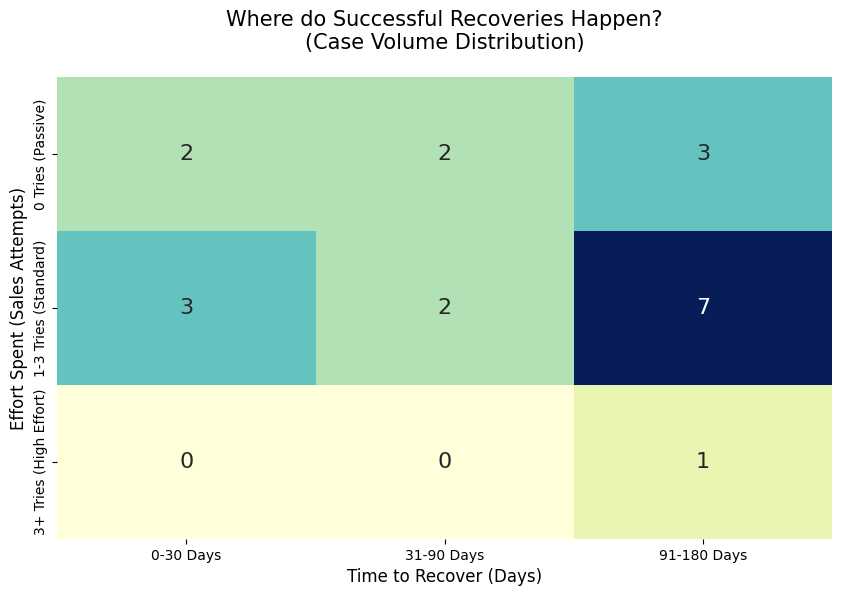

In [18]:
df_plot = df_recovery[df_recovery['Days_to_Recover'] <= 180].copy()

df_plot['Time_Bucket'] = pd.cut(df_plot['Days_to_Recover'],bins=[-1, 30, 90, 180],labels=['0-30 Days', '31-90 Days', '91-180 Days'])

df_plot['Effort_Bucket'] = pd.cut(df_plot['Recovery_Tries'],bins=[-1, 0, 3, 100],labels=['0 Tries (Passive)', '1-3 Tries (Standard)', '3+ Tries (High Effort)'])

matrix_data = pd.crosstab(df_plot['Effort_Bucket'], df_plot['Time_Bucket'])

plt.figure(figsize=(10, 6))
sns.heatmap(matrix_data, annot=True, cmap="YlGnBu", fmt='d', cbar=False, annot_kws={"size": 16})

plt.title('Where do Successful Recoveries Happen?\n(Case Volume Distribution)', fontsize=15, pad=20)
plt.xlabel('Time to Recover (Days)', fontsize=12)
plt.ylabel('Effort Spent (Sales Attempts)', fontsize=12)

plt.show()

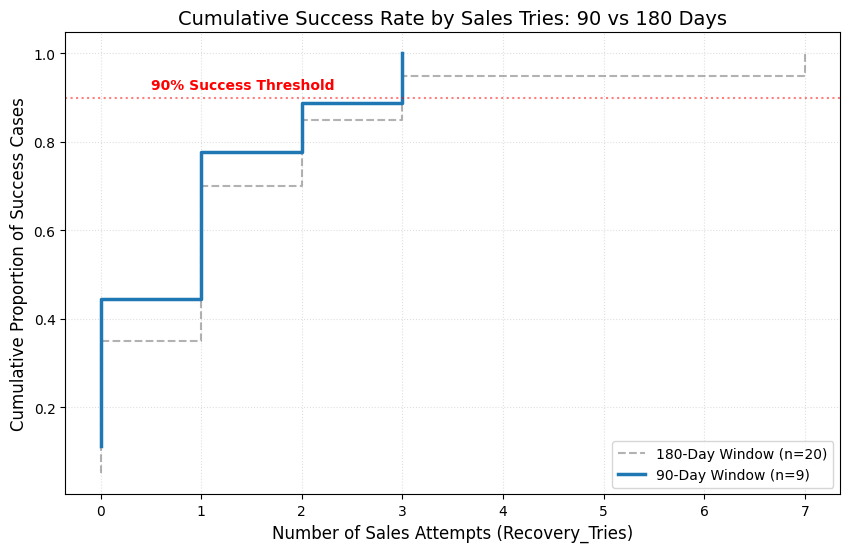

In [19]:
def get_cdf(data):
    y = np.arange(1, len(data) + 1) / len(data)
    return data, y

x_90, y_90 = get_cdf(df_90['Recovery_Tries'].sort_values())
x_180, y_180 = get_cdf(df_180['Recovery_Tries'].sort_values())

plt.figure(figsize=(10, 6))
plt.step(x_180, y_180, label=f'180-Day Window (n={len(df_180)})',
         where='post', color='gray', linestyle='--', alpha=0.6)

plt.step(x_90, y_90, label=f'90-Day Window (n={len(df_90)})',
         where='post', color='#1f77b4', linewidth=2.5)

plt.axhline(y=0.9, color='red', linestyle=':', alpha=0.5)
plt.text(0.5, 0.92, '90% Success Threshold', color='red', fontweight='bold')

plt.title('Cumulative Success Rate by Sales Tries: 90 vs 180 Days', fontsize=14)
plt.xlabel('Number of Sales Attempts (Recovery_Tries)', fontsize=12)
plt.ylabel('Cumulative Proportion of Success Cases', fontsize=12)
plt.xticks(np.arange(0, max(x_180)+1, 1))
plt.grid(axis='both', linestyle=':', alpha=0.4)
plt.legend(loc='lower right')

plt.show()

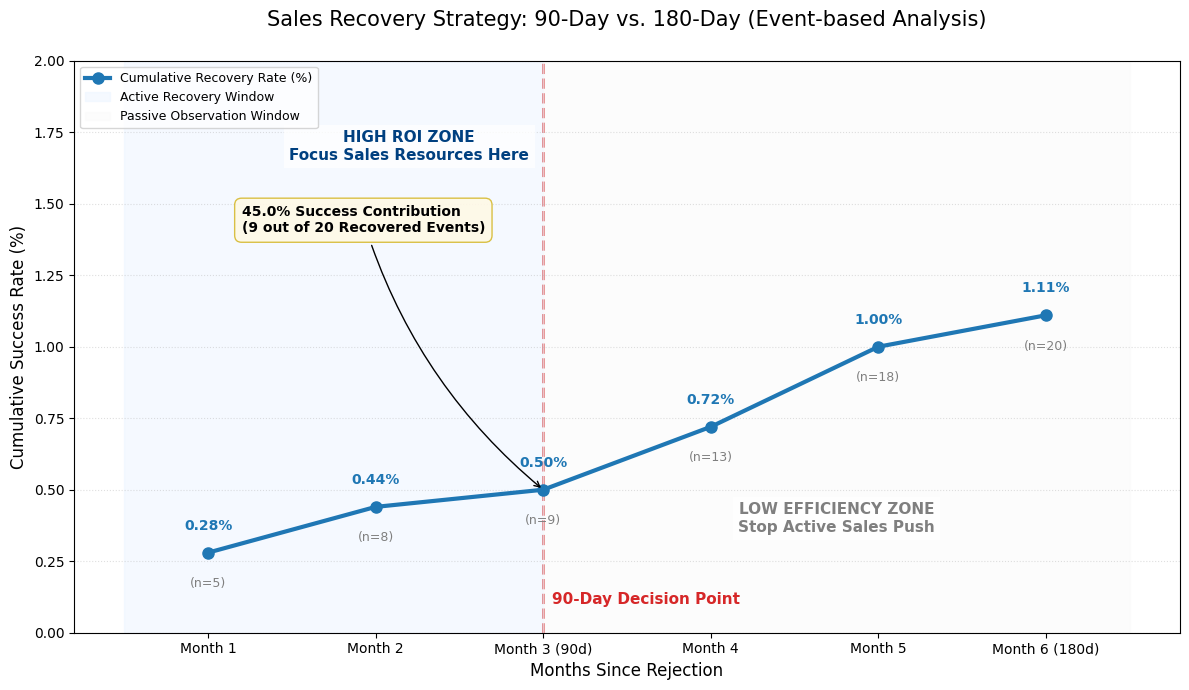

In [20]:
df_180['Month'] = np.ceil(df_180['Days_to_Recover'] / 30).clip(lower=1, upper=6).astype(int)
counts_series = df_180.groupby('Month').size().reindex(range(1, 7), fill_value=0).cumsum()
counts = counts_series.values.tolist()

months = [1, 2, 3, 4, 5, 6]
total_events = 1805
rates = [round((c / total_events) * 100, 2) for c in counts]

plt.figure(figsize=(12, 7))
plt.plot(months, rates, marker='o', color='#1f77b4', linewidth=3, markersize=8, label='Cumulative Recovery Rate (%)')

plt.axvline(x=3, color='#d62728', linestyle='--', linewidth=2, zorder=1)
plt.text(3.05, 0.1, '90-Day Decision Point', color='#d62728', fontweight='bold', fontsize=11)

plt.axvspan(0.5, 3, color='#e6f2ff', alpha=0.4, label='Active Recovery Window')
plt.axvspan(3, 6.5, color='#f9f9f9', alpha=0.4, label='Passive Observation Window')

plt.text(2.2, 1.7, 'HIGH ROI ZONE\nFocus Sales Resources Here',
         ha='center', va='center', color='#004080', fontweight='bold', fontsize=11,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.text(4.75, 0.4, 'LOW EFFICIENCY ZONE\nStop Active Sales Push',
         ha='center', va='center', color='#7f7f7f', fontweight='bold', fontsize=11,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

for i, (r, c) in enumerate(zip(rates, counts)):
    plt.text(months[i], r + 0.08, f'{r:.2f}%', ha='center', color='#1f77b4', fontweight='bold', fontsize=10)
    plt.text(months[i], r - 0.12, f'(n={c})', ha='center', color='#7f7f7f', fontsize=9)

n_90 = counts[2]
n_180 = counts[5]
contribution_pct = round((n_90 / n_180) * 100, 1) if n_180 > 0 else 0

plt.annotate(f'{contribution_pct}% Success Contribution\n({n_90} out of {n_180} Recovered Events)',
             xy=(3, rates[2]), xytext=(1.2, 1.4),
             arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.15", color='black', lw=1),
             bbox=dict(boxstyle="round,pad=0.5", fc="#fff9e6", ec="#d6ba32", alpha=0.9),
             fontsize=10, fontweight='bold')

plt.title('Sales Recovery Strategy: 90-Day vs. 180-Day (Event-based Analysis)', fontsize=15, pad=25)
plt.xlabel('Months Since Rejection', fontsize=12)
plt.ylabel('Cumulative Success Rate (%)', fontsize=12)
plt.xticks(months, ['Month 1', 'Month 2', 'Month 3 (90d)', 'Month 4', 'Month 5', 'Month 6 (180d)'])
plt.ylim(0, 2.0)
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

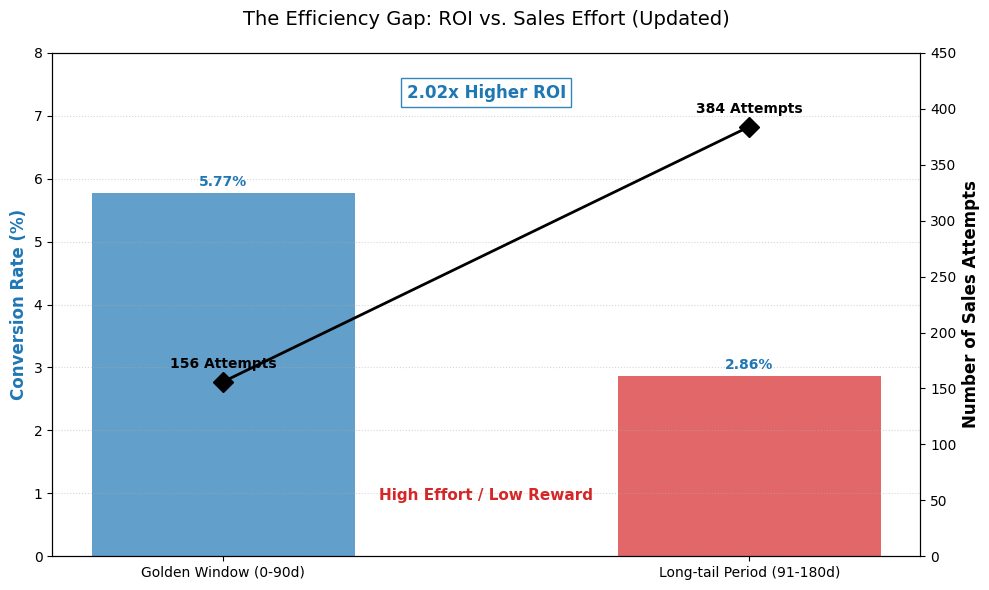

In [21]:
labels = ['Golden Window (0-90d)', 'Long-tail Period (91-180d)']
attempts = [156, 384]
conv_rates = [5.77, 2.86] #根據個成功次數9,11除返個attempts得出
fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(labels, conv_rates, color=['#1f77b4', '#d62728'], alpha=0.7, width=0.5)
ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold', color='#1f77b4')
ax1.set_ylim(0, 8)

ax2 = ax1.twinx()
ax2.plot(labels, attempts, color='black', marker='D', markersize=10, linewidth=2)
ax2.set_ylabel('Number of Sales Attempts', fontsize=12, fontweight='bold', color='black')
ax2.set_ylim(0, 450)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height:.2f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold', color='#1f77b4')

for i, txt in enumerate(attempts):
    ax2.annotate(f'{txt} Attempts', xy=(labels[i], attempts[i]),
                 xytext=(0, 10), textcoords="offset points", ha='center', fontweight='bold', color='black')

plt.text(0.5, 410, '2.02x Higher ROI', color='#1f77b4', fontsize=12, fontweight='bold',
         ha='center', bbox=dict(facecolor='white', alpha=0.9, edgecolor='#1f77b4'))
plt.text(0.5, 50, 'High Effort / Low Reward', color='#d62728', fontsize=11, fontweight='bold', ha='center')

plt.title('The Efficiency Gap: ROI vs. Sales Effort (Updated)', fontsize=14, pad=20)
ax1.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()